# 01_回归算法-决策树回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们聊聊决策树回归\~

决策树回归（Decision Tree Regression）是一种用来做数值预测的机器学习算法，核心思想就是 **“用一棵树来做决定”**。

**什么是决策树回归？**

你可以把它想象成玩“20 问题”游戏：

假设你要预测一个房子的价格，你可以问：

- **房子有多大？**（如果大于100㎡，走左边；否则，走右边）
- **地段好不好？**（如果是市中心，走左边；否则，走右边）
- **装修豪华吗？**（是的话，走左边；否则，走右边）

你一步步问问题，把所有房子分成不同的小组，最终，每个小组都会有一个大致的房价预测值。这个 **“问问题 -> 划分 -> 预测”** 的过程，就是决策树回归的基本原理。

### 它是怎么工作的？

1. **把数据分组**：先找出一个关键的“分割点”（比如面积大小），把数据切成两部分，让每个部分的数据更“纯”（类似的数值聚在一起）。
2. **继续划分**：对每个部分再找合适的分割点，继续细分，直到满足某个停止条件（比如数据量太少，或者数据已经足够纯）。
3. **生成预测值**：当数据不能再分时，取每个小组的数据平均值，作为最终的预测值。

## 原理详解

决策树回归的核心思想是通过一系列的 **二元划分**（将数据分成两个部分），基于不同的特征和数值条件来进行预测。

每次划分都在尽量使得每个划分后的数据组（子集）具有较小的方差，从而使得每个小组内的数据尽可能相似。最终，在叶子节点上进行数值预测，通常是该区域数据点的 **均值**。

### 算法流程

决策树回归的算法流程可以分为以下几个步骤：

1. **选择最佳特征进行划分**：

   - 对于每个特征，尝试不同的分割点（阈值）来划分数据，找到使得预测误差最小的划分方式。
2. **根据误差（损失函数）进行分裂**：

   - 每次划分时，我们会评估如何分裂特征，使得每个子集内的“纯度”最大化。对于回归问题，**纯度**通常通过 **均方误差（MSE）** 来衡量。
3. **递归分裂**：

   - 对每个子集继续递归地进行划分，直到达到停止条件。停止条件可以是：
   
     - 达到预设的树的最大深度
     - 每个叶子节点中的数据点数目低于某个阈值
     - 数据已经无法进一步改善预测的误差
4. **预测**：

   - 对于每个新数据点，根据决策树的规则沿着树的分支走，最终到达某个叶子节点，该叶子节点的预测值就是该区域数据点的均值。

### 数学推导和公式

#### 1. 损失函数：均方误差（MSE）

在回归任务中，常见的损失函数是 **均方误差（MSE）**，用来度量数据点与模型预测值之间的差距。对于一组数据 $\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$，均方误差定义为：


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


其中，$\hat{y}_i$ 是对于输入特征 $x_i$ 的预测值。决策树回归的目标是最小化这个误差。

#### 2. 在节点划分中的损失评估：

在决策树回归中，选择如何划分节点的依据是最小化 **节点划分后的均方误差（MSE）**。假设我们在节点 $T$ 上选择了一个特征 $X_j$ 进行划分，使用阈值 $v$ 来将数据划分为两部分：左子节点和右子节点。

- **左子节点**包含所有满足 $X_j \leq v$ 的数据点。
- **右子节点**包含所有满足 $X_j > v$ 的数据点。

对于节点 $T$，假设左子节点的均方误差是 $\text{MSE}_{\text{left}}$，右子节点的均方误差是 $\text{MSE}_{\text{right}}$，则总的均方误差为：


$$
\text{MSE}_T = \frac{n_{\text{left}}}{n_T} \cdot \text{MSE}_{\text{left}} + \frac{n_{\text{right}}}{n_T} \cdot \text{MSE}_{\text{right}}
$$


其中：

$n_T$ 是节点 $T$ 的样本数

$n_{\text{left}}$ 和 $n_{\text{right}}$ 分别是左子节点和右子节点的样本数

#### 3. 计算子节点的均方误差（MSE）

对于每个子节点 $T_{\text{left}}$ 和 $T_{\text{right}}$，它们的均方误差 $\text{MSE}_{\text{left}}$ 和 $\text{MSE}_{\text{right}}$ 分别定义为：

$\text{MSE}_{\text{left}} = \frac{1}{n_{\text{left}}} \sum_{i \in T_{\text{left}}} (y_i - \hat{y}_{\text{left}})^2$  
$\text{MSE}_{\text{right}} = \frac{1}{n_{\text{right}}} \sum_{i \in T_{\text{right}}} (y_i - \hat{y}_{\text{right}})^2$

其中：

$\hat{y}_{\text{left}}$ 是左子节点样本的预测均值，通常取左子节点所有样本 $y_i$ 的均值。

$\hat{y}_{\text{right}}$ 是右子节点样本的预测均值，通常取右子节点所有样本 $y_i$ 的均值。

#### 4. 寻找最优的划分点

在决策树的训练过程中，目标是通过遍历所有可能的特征和划分点，选择 **使得MSE最小的划分**。具体来说：

- 对于每个特征 $X_j$，遍历该特征的所有可能值（或预先定义的一些阈值）作为划分点。
- 对于每个划分点，计算对应的 **均方误差**。
- 选择 **MSE最小的划分点**。

### 停止条件

决策树的生成过程中通常会设置一些停止条件，例如：

- **树的最大深度**：限制树的深度，避免树生长得过大。
- **最小样本数**：每个节点最小样本数不能少于某个阈值。
- **最小增益**：如果划分后的均方误差减少小于某个阈值，则停止划分。

### 叶子节点的预测

在回归树的叶子节点中，最终的预测值是该叶子节点中所有样本的 **均值**。假设在某个叶子节点中，包含了样本 $\{(x_1, y_1), (x_2, y_2), \dots, (x_m, y_m)\}$，该叶子节点的预测值 $\hat{y}$ 为：


$$
\hat{y} = \frac{1}{m} \sum_{i=1}^{m} y_i
$$


整个这个过程类似于在做一次 **“区域划分”**，每次通过选择合适的特征和划分点，使得每个区域内的样本尽可能相似，从而能够做出更精确的数值预测。

## 完整案例

我们使用一个公开的房价数据集，展示如何应用决策树回归，并进行模型优化。

#### 1. 数据准备

首先，我们需要一个房价数据集。我们使用的是 **California Housing** 数据集，包含多个特征，如房屋的平均房间数、家庭收入、地区、房屋的年龄等。

#### 2. 数据加载与初步分析

我们将使用 `sklearn.datasets` 加载 California Housing 数据集。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# 加载 California Housing 数据集
data = load_local_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 数据集基本信息
print(X.head())  # 显示前5行数据
print(y.head())  # 显示前5行目标值

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  3.1838      20.0  3.783465   1.094488       525.0  2.066929     32.79   
1  4.4871       2.0  6.690700   1.166144      3327.0  3.476489     38.01   
2  3.2237      31.0  4.657928   1.064919      2313.0  2.887640     33.92   
3  2.8920      30.0  5.701357   1.248869       707.0  3.199095     37.94   
4  4.1016       4.0  4.709328   1.295011       928.0  2.013015     37.99   

   Longitude  
0    -117.24  
1    -121.29  
2    -118.14  
3    -122.07  
4    -121.89  
0    2.458
1    1.379
2    2.182
3    2.208
4    1.705
dtype: float64


#### 3. 数据可视化

在分析数据之前，我们需要对数据进行可视化，查看特征之间的关系。

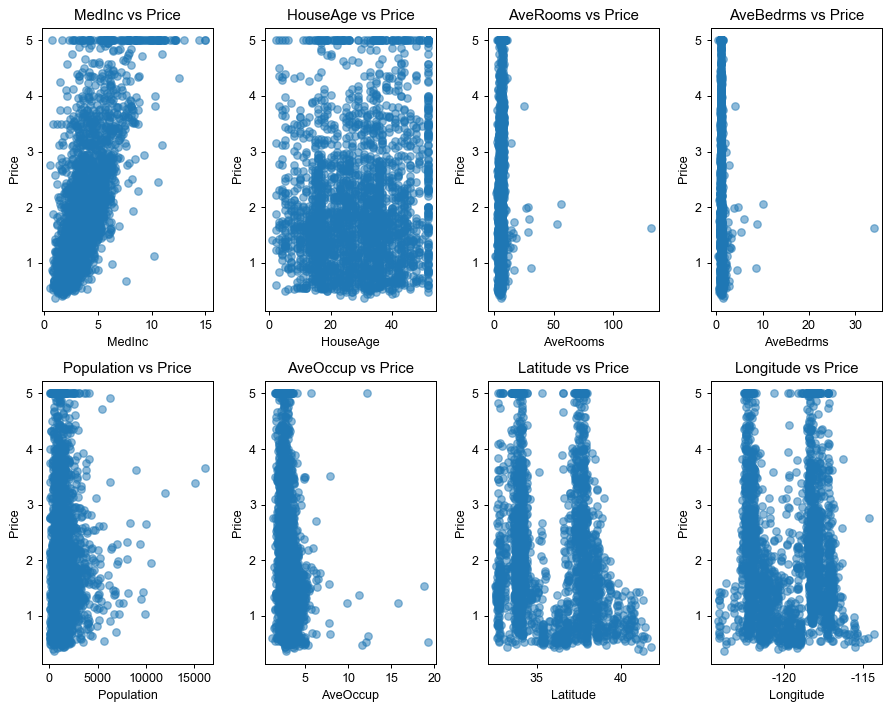

In [3]:
# 可视化特征之间的关系
plt.figure(figsize=(10, 8))

for i, column in enumerate(X.columns):
    plt.subplot(2, 4, i+1)
    plt.scatter(X[column], y, alpha=0.5)
    plt.title(f'{column} vs Price')
    plt.xlabel(column)
    plt.ylabel('Price')

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

#### 4. 数据预处理与划分

在进行模型训练之前，我们需要进行数据预处理。特别地，我们需要标准化特征数据，并将数据划分为训练集和测试集。

In [4]:
# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#### 5. 决策树回归模型

接下来，我们使用决策树回归算法来训练模型。

In [5]:
# 使用决策树回归
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 预测训练集和测试集
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 评估模型
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training MSE: {train_mse:.2f}")
print(f"Testing MSE: {test_mse:.2f}")
print(f"Training R^2: {train_r2:.2f}")
print(f"Testing R^2: {test_r2:.2f}")

Training MSE: 0.00
Testing MSE: 0.67
Training R^2: 1.00
Testing R^2: 0.47


- 我们通过 **均方误差（MSE）** 和 **决定系数（R²）** 来评估模型的性能。
- 如果训练集的 R² 很高而测试集的 R² 较低，说明模型有可能 **过拟合**。

#### 6. 可视化决策树

为了更好地理解模型，我们可以可视化训练得到的决策树。

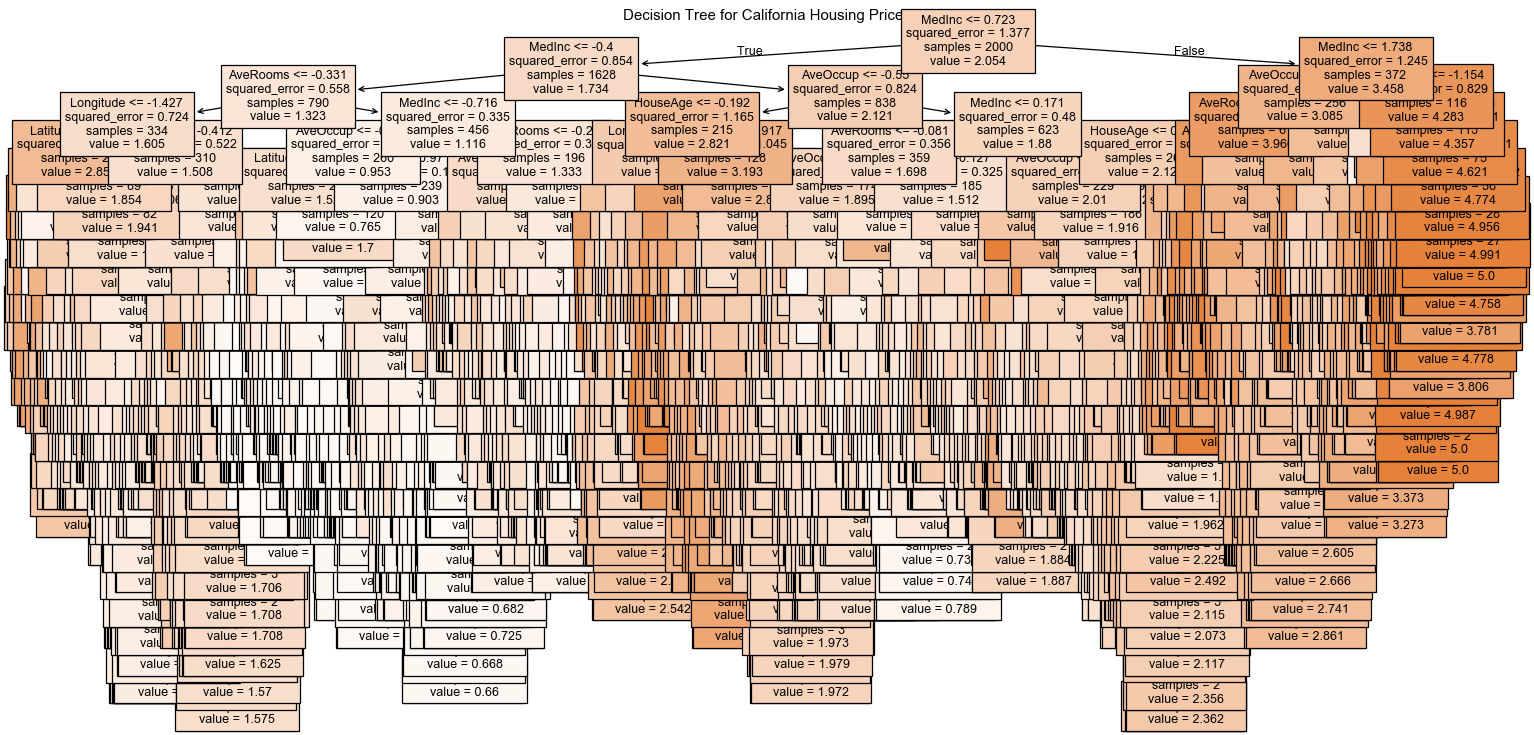

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=X.columns, fontsize=10)
plt.title("Decision Tree for California Housing Prices")
plt.show()

通过树形结构可以看到每个分裂的条件和特征，这有助于理解模型是如何做出决策的。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

#### 7. 模型优化：调参

决策树回归算法的性能很大程度上受 **树的深度**、**最小样本叶子节点数**等参数的影响。

可以使用 **网格搜索（GridSearchCV）** 来优化这些参数。

In [7]:
# 定义参数范围
param_grid = {
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [None, 'sqrt']
}

# 使用网格搜索进行交叉验证
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最佳参数和得分
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation MSE:", -grid_search.best_score_)

# 使用最佳参数训练模型
best_model = grid_search.best_estimator_
y_test_pred_optimized = best_model.predict(X_test)

# 评估优化后的模型
test_mse_optimized = mean_squared_error(y_test, y_test_pred_optimized)
test_r2_optimized = r2_score(y_test, y_test_pred_optimized)

print(f"Optimized Testing MSE: {test_mse_optimized:.2f}")
print(f"Optimized Testing R^2: {test_r2_optimized:.2f}")

Best parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation MSE: 0.6057521974125566
Optimized Testing MSE: 0.56
Optimized Testing R^2: 0.56


#### 8. 模型比较与总结

在模型优化后，我们会比较优化前后的 MSE 和 R² 值：

In [8]:
# 比较优化前后的表现
print(f"Before Optimization - Testing MSE: {test_mse:.2f}, Testing R^2: {test_r2:.2f}")
print(f"After Optimization - Testing MSE: {test_mse_optimized:.2f}, Testing R^2: {test_r2_optimized:.2f}")

Before Optimization - Testing MSE: 0.67, Testing R^2: 0.47
After Optimization - Testing MSE: 0.56, Testing R^2: 0.56


通过网格搜索和超参数调整，通常可以得到更好的模型性能，尤其是在控制过拟合的情况下。

#### 9. 结果可视化：模型的预测 vs 真实值

最后，我们将绘制模型的预测值与真实值的对比图，进一步验证优化后模型的表现。

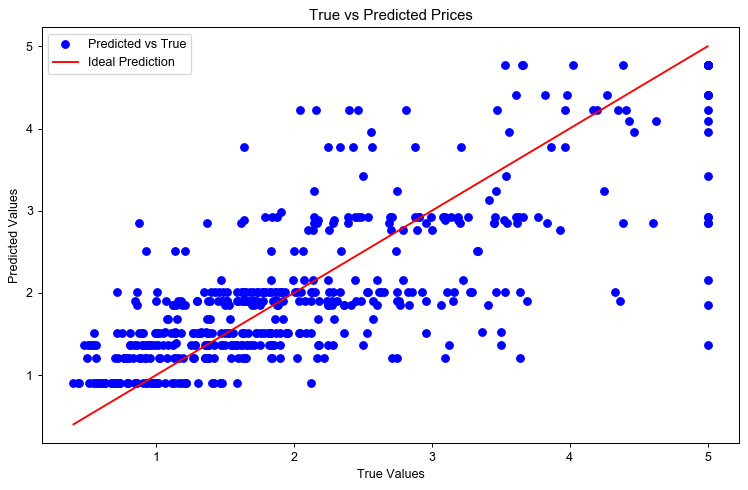

In [9]:
# 可视化真实值和预测值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_optimized, color='blue', label='Predicted vs True')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Ideal Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Prices')
plt.legend()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

理想情况下，预测值应该与真实值完全一致，图中的红线表示这种理想关系。如果点分布接近红线，说明模型效果较好。

## 模型分析

### 决策树回归模型优缺点

**优点：**

1. **易于理解与解释**：决策树回归是一个非常直观的模型，其工作原理和决策过程可以通过树形结构展示，这使得用户很容易理解特征对预测结果的影响。在需要模型解释性的场景中，决策树回归非常有优势。
2. **无需特征缩放**：与其他一些回归模型（如支持向量机回归）不同，决策树回归不受特征缩放的影响。无论输入特征的范围是多少，都无需进行归一化或标准化处理，这简化了预处理过程。
3. **能够处理非线性关系**：决策树回归能够有效地处理特征之间的非线性关系，这使得它非常适用于复杂的预测任务。
4. **可以处理类别特征**：决策树回归可以直接处理类别数据，无需额外的转换。它会根据不同类别特征来进行划分，这在某些实际问题中非常有用。

**缺点：**

1. **容易过拟合**：决策树模型如果没有进行适当的剪枝或设置合理的参数，它可能会对训练数据过度拟合，导致在测试集上的泛化能力差。特别是在数据集较小或特征较多时，过拟合问题尤为突出。
2. **模型不稳定**：决策树对于数据的微小变化比较敏感，训练数据的小幅波动可能会导致树形结构发生显著变化。这种不稳定性在实际应用中可能是一个问题，特别是在对模型鲁棒性要求较高的场景中。
3. **对噪声敏感**：决策树容易受到噪声数据的影响，尤其是在存在异常值的情况下，模型可能会产生不合理的预测。这是因为决策树会试图根据噪声数据划分每个节点，从而降低模型的可靠性。
4. **计算复杂度较高**：虽然决策树的单个节点计算不复杂，但当树的深度增大时，计算复杂度会增加。特别是当数据维度和样本数非常大时，训练一个复杂的决策树可能需要较长时间。

### 决策树回归与相似算法的对比

| **算法** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|
| **决策树回归** | \* 直观易懂，能够解释特征影响  <br/>\* 能处理复杂的非线性关系  <br/>\* 不需要特征缩放 | \* 容易过拟合  <br/>\* 对噪声敏感  <br/>\* 树结构不稳定 | 适用于数据特征之间存在复杂关系的场景，且易于解释的需求场景（例如，房价预测）。 |
| **线性回归** | \* 简单高效  <br/>\* 计算开销小  <br/>\* 适用于特征之间存在线性关系的场景 | \* 仅适用于线性关系  <br/>\* 对异常值敏感  <br/>\* 不能处理复杂的非线性关系 | 数据特征之间存在线性关系时，例如简单的预测任务或拟合线性趋势。 |
| **支持向量回归 (SVR)** | \* 强大的分类能力，适用于高维数据  <br/>\* 能够处理非线性问题（使用核函数） | \* 对参数调优要求高  <br/>\* 计算开销较大  <br/>\* 不适合非常大的数据集 | 适用于高维数据或者特征之间存在复杂关系的任务，特别是需要较高精度的预测。 |
| **随机森林回归** | \* 较好的抗过拟合能力  <br/>\* 能够处理高维数据并自动进行特征选择 | \* 训练时间较长  <br/>\* 模型较难解释  <br/>\* 对噪声较为敏感 | 在训练数据集较大时，且需要较高的预测精度，特别是特征之间复杂且具有相关性时。 |
| **梯度提升回归（GBR）** | \* 强大的预测能力，能够处理复杂关系  <br/>\* 适用于高维数据和大数据集 | \* 模型训练时间长  <br/>\* 对参数非常敏感  <br/>\* 可能容易过拟合 | 在需要非常高预测精度的任务中，尤其是当数据存在复杂非线性关系时，且模型训练时间不是问题。 |

### 何时使用决策树回归？

**决策树回归优选情况**：

1. **需要直观的模型解释**：如果需要一个能够清晰解释的模型，特别是在特征对预测结果有明确影响时，决策树回归非常合适。其树形结构让模型的决策过程一目了然，便于展示给非技术人员理解。
2. **数据具有复杂的非线性关系**：当数据特征之间的关系较为复杂，可能表现为非线性时，决策树回归能够有效捕捉这种复杂性，尤其是当线性回归无法提供准确预测时。
3. **缺少特征预处理**：如果数据没有经过标准化处理或特征缩放，决策树回归能够处理这种情况，因为它不依赖于特征的尺度。这对于数据预处理不充分的场景尤其有用。
4. **类别特征的处理**：如果数据包含类别特征，决策树回归能够直接处理这些特征，无需转换成数值型变量，因此特别适合混合型数据。

**考虑其他算法的情况**：

1. **需要高精度且对过拟合敏感的情况**：当需要在数据较复杂的情况下进行高精度预测时，决策树回归可能会因过拟合而表现不佳。此时可以考虑使用 **随机森林回归** 或 **梯度提升回归**，它们能够通过集成学习减少过拟合的风险，并提供更稳定的预测。
2. **数据量大且计算开销较大时**：决策树回归可能需要长时间进行训练，尤其是当数据集非常大且树的深度较深时。在这种情况下，可能需要考虑 **线性回归**（如果数据特征之间存在线性关系）或者 **支持向量回归（SVR）**，后者能够在高维空间中处理复杂的非线性关系。
3. **特征之间存在线性关系时**：如果特征和目标变量之间存在线性关系，使用 **线性回归** 会更简单、快速，并且易于理解。线性回归通常能够提供较好的预测效果，尤其是当数据集的规模较小时。
4. **对噪声数据非常敏感时**：如果数据集包含较多噪声或异常值，决策树回归可能会过拟合噪声数据。在这种情况下，可以使用 **支持向量回归** 或 **随机森林回归**，它们对噪声数据具有更好的鲁棒性。

### 总结

**决策树回归** 适合在数据特征间关系复杂且需要较高模型可解释性的任务中使用，但在面对 **过拟合问题** 或 **数据噪声** 时，需要进行优化（如剪枝或使用集成方法）。

**随机森林** 和 **梯度提升回归** 是处理高维和复杂关系的强大工具，能提供更高的预测精度，适用于较为复杂的任务，但训练时间较长且模型不易解释。

**线性回归** 和 **支持向量回归** 在数据线性可分且对模型精度要求不高时是良好的选择。